## Training an Autoregressive Transformer for Next-Character Prediction

In [ ]:
# imports

import torch
import torch.nn as nn 
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

In [ ]:
# have a look at what the toy data looks like
from src.utils import load_toy

(train, test), (i2c, c2i) = load_toy(final=False)

print("".join([i2c[idx] for idx in train[:100]]))

the short man goes ( for the gorgeous bear ) . the koala walks to the lawyer . a willowy businesswom


## 1) Baseline: MLP

In [24]:
from src.train_baseline import run

train_loss, val_loss, val_acc, model, test_acc, sampled_sentence = run()

cuda
[2.8891576027870176, 2.320036015510559, 2.043730566501617, 1.7638247138261796, 1.6725513637065887, 1.467441074848175, 1.313814134001732, 1.242219834625721, 1.1228997400403022, 1.0216119807958604, 0.9943262225389481, 0.9468492472171783, 0.7809596204757691, 0.7854521948099137, 0.7742162503302097, 0.6958256097137928, 0.6493954686820507, 0.6868091338872909, 0.7270397132635117, 0.6210064581036567]
[2.5140244245529173, 2.0462109625339506, 1.924207204580307, 1.830614060163498, 1.54503875374794, 1.6125036954879761, 1.22086221575737, 1.093628366291523, 1.233379417657852, 0.9566385641694068, 1.005002897977829, 0.9146085143089294, 0.8754180103540421, 0.8709080919623375, 0.840021601319313, 0.7463169628754258, 0.7229354768991471, 0.6852562457323075, 0.691174590587616, 0.6668880969285965]
[0.265625, 0.39375, 0.390625, 0.459375, 0.51875, 0.490625, 0.615625, 0.653125, 0.63125, 0.684375, 0.678125, 0.70625, 0.709375, 0.709375, 0.71875, 0.746875, 0.753125, 0.771875, 0.7875, 0.759375]
test loss: 0.68

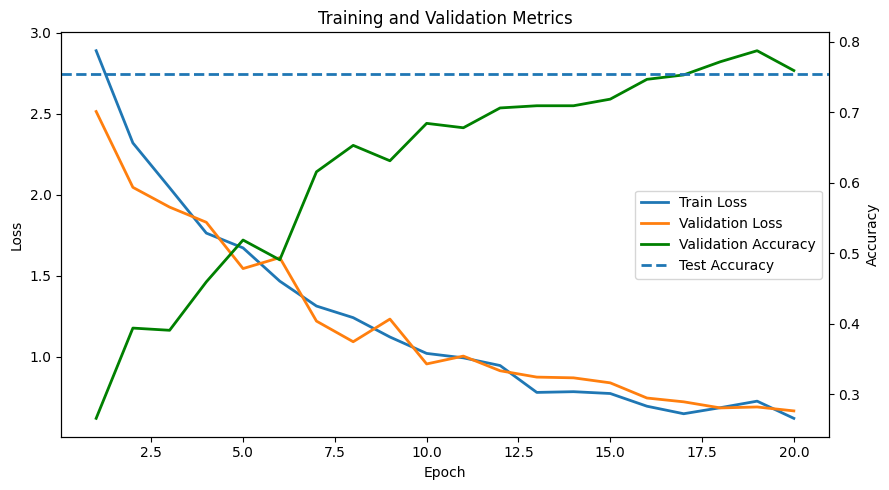

In [29]:
# plot results
epochs = range(1, len(train_loss) + 1)

fig, ax1 = plt.subplots(figsize=(9, 5))

# left y-axis: loss
line1, = ax1.plot(epochs, train_loss, label="Train Loss", linewidth=2)
line2, = ax1.plot(epochs, val_loss, label="Validation Loss", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Validation Metrics")

# right y-axis: accuracy
ax2 = ax1.twinx()
line3, = ax2.plot(epochs, val_acc, label="Validation Accuracy", linewidth=2, color="green")
line4 = ax2.axhline(y=test_acc, label="Test Accuracy", linestyle="--", linewidth=2)
ax2.set_ylabel("Accuracy")

# combined legend
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="center right")

plt.tight_layout()
plt.show()

The MLP that was used as a baseline has the following architecture and hyperparameters:

Architecture:
* 3 layers with ReLU non-linearities after layer 1 and 2
* embedding_dim: 30
* sequence length: 64
* input_dim: 64 * 30 = 1920
* hidden_dim: 512
* output_dim: 31

Hyperparameter:
* epochs: 20
* batch_size: 16
* learing_rate: 0.001

To simplify the setup, we first used a classification-based baseline instead of a fully autoregressive model. The input sequence was only used to predict one single next token, namely the token at position sequence_length + 1, rather than predicting the next token at every position.

Despite this simple setup and the roughly chosen hyperparameters, the model still reached a test accuracy of 73%. This already suggests how much easier the task becomes on the artificially constructed toy data. Even in the sampled output, some recognizable structure can be seen, including plausible syllables and occasional complete words.

## 2) Model: Autoregressive Transformer

In [16]:
# default experiment
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.utils import load_config
from src.train import run_one_experiment

# run default autoregressive transformer on the toy data
cfg = load_config("../configs/default_config.yaml")
results = run_one_experiment(cfg)

print(f"Best epoch: {results['best_epoch']}")
print(f"Test loss: {results['test_loss']:.4f}")
print(f"Test acc: {results['test_acc']:.4f}")
print(results["sample_sentence"])

Epoch 1/50 | Train Loss: 1.9162 | Val Last-Token Loss: 1.6042 | Val Accuracy: 0.4425
Epoch 2/50 | Train Loss: 0.7725 | Val Last-Token Loss: 0.4800 | Val Accuracy: 0.8387
Epoch 3/50 | Train Loss: 0.4974 | Val Last-Token Loss: 0.4093 | Val Accuracy: 0.8400
Epoch 4/50 | Train Loss: 0.4517 | Val Last-Token Loss: 0.3985 | Val Accuracy: 0.8488
Epoch 5/50 | Train Loss: 0.4363 | Val Last-Token Loss: 0.3883 | Val Accuracy: 0.8387
Epoch 6/50 | Train Loss: 0.4305 | Val Last-Token Loss: 0.4150 | Val Accuracy: 0.8400
Epoch 7/50 | Train Loss: 0.4255 | Val Last-Token Loss: 0.4807 | Val Accuracy: 0.8063
Epoch 8/50 | Train Loss: 0.4232 | Val Last-Token Loss: 0.4107 | Val Accuracy: 0.8500
Epoch 9/50 | Train Loss: 0.4191 | Val Last-Token Loss: 0.3900 | Val Accuracy: 0.8488
Epoch 10/50 | Train Loss: 0.4167 | Val Last-Token Loss: 0.4427 | Val Accuracy: 0.8137
Epoch 11/50 | Train Loss: 0.4149 | Val Last-Token Loss: 0.3782 | Val Accuracy: 0.8400
Epoch 12/50 | Train Loss: 0.4138 | Val Last-Token Loss: 0.4102 

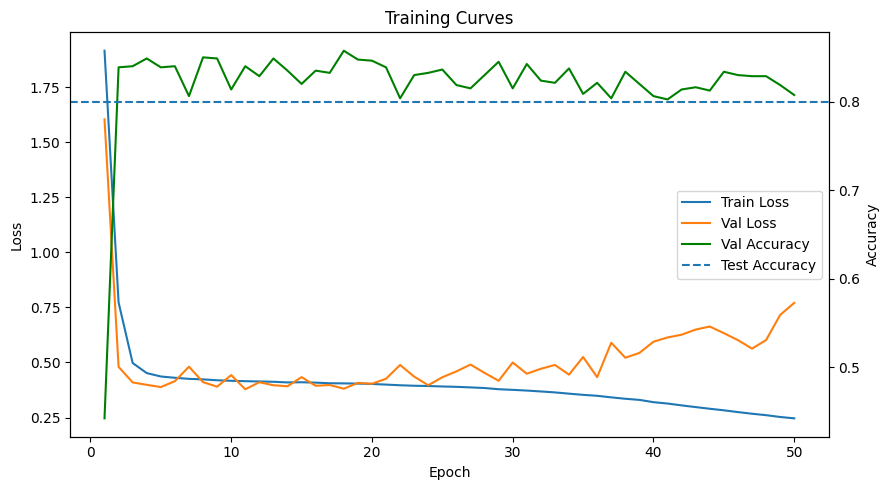

In [22]:
# plot default run
import matplotlib.pyplot as plt

def plot_training_curves(results):
    epochs = range(1, len(results["train_loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(9, 5))

    # left axis: loss
    ax1.plot(epochs, results["train_loss"], label="Train Loss", linewidth=1.5)
    ax1.plot(epochs, results["val_loss"], label="Val Loss", linewidth=1.5)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    # right axis: accuracy
    ax2 = ax1.twinx()
    ax2.plot(epochs, results["val_acc"], label="Val Accuracy", linewidth=1.5, color="green")
    ax2.axhline(results["test_acc"], linestyle="--", linewidth=1.5, label="Test Accuracy")
    ax2.set_ylabel("Accuracy")

    # combined legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

    plt.title("Training Curves")
    plt.tight_layout()
    plt.show()

plot_training_curves(results)

The autoregressive transformer shows very fast and effective learning on the toy dataset. Both training and validation loss drop sharply within the first few epochs, while validation accuracy quickly rises to around 0.8, indicating that the model captures the underlying structure of the language-like data very efficiently. The generated sample supports this impression, as it already contains clear structure and plausible word-like patterns.

For this run, the model used 6 attention heads, 4 transformer blocks, an embedding dimension of 300, dropout 0.3, learning rate 0.001, batch size 32, and a context length of 128 on GPU. Since early stopping was effectively disabled here (patience = 50 for a 50-epoch run), the curves also show clear signs of beginning overfitting toward the end: the training loss continues to decrease steadily, while the validation loss starts to rise again after its minimum. Overall, this suggests that the model learns the toy language very well and very quickly. This makes it especially interesting to test the same autoregressive setup on a more realistic dataset with natural language.

### 2.1) Random Search

Although proper hyperparameter tuning seems not necessary here, as the toy data appears to be relatively easy for the autoregressive transformer, a small random search was performed nevertheless to explore the sensitivity of the model to different settings. This serves less as a requirement for good performance and more as a sanity check, showing whether the model is robust across a range of reasonable hyperparameter choices and giving a first impression of which configurations tend to work well.

In [2]:
# random search over some hyperparameter
from src.train import random_search

cfg = load_config("../configs/default_config.yaml")
all_results = random_search(cfg, n_trials=20, seed=111)

[sampled config] Trial 1: lr=0.005505, dropout=0.2, emb=256, blocks=5, heads=4, bsz=16
Epoch 1/25 | Train Loss: 3.8084 | Val Last-Token Loss: 1.8451 | Val Accuracy: 0.3600
Epoch 2/25 | Train Loss: 1.8531 | Val Last-Token Loss: 1.9042 | Val Accuracy: 0.3525
Epoch 3/25 | Train Loss: 1.5063 | Val Last-Token Loss: 1.1780 | Val Accuracy: 0.6125
Epoch 4/25 | Train Loss: 1.0235 | Val Last-Token Loss: 0.7798 | Val Accuracy: 0.7275
Epoch 5/25 | Train Loss: 0.7644 | Val Last-Token Loss: 0.6630 | Val Accuracy: 0.7825
Epoch 6/25 | Train Loss: 0.6443 | Val Last-Token Loss: 0.5164 | Val Accuracy: 0.8050
Epoch 7/25 | Train Loss: 0.5792 | Val Last-Token Loss: 0.4792 | Val Accuracy: 0.7925
Epoch 8/25 | Train Loss: 0.5423 | Val Last-Token Loss: 0.4273 | Val Accuracy: 0.8350
Epoch 9/25 | Train Loss: 0.5000 | Val Last-Token Loss: 0.4473 | Val Accuracy: 0.8200
Epoch 10/25 | Train Loss: 0.4827 | Val Last-Token Loss: 0.4844 | Val Accuracy: 0.8150
Epoch 11/25 | Train Loss: 0.4664 | Val Last-Token Loss: 0.4687

In [15]:
import pandas as pd

df = pd.DataFrame(all_results)
df = df.sort_values("best_val_acc", ascending=False)
df.head(10)

,trial,seed,lr,dropout,embedding_dim,num_Tblocks,num_heads,bsz,best_epoch,best_val_loss,best_val_acc,test_loss,test_acc
16,17,42,0.000768,0.0,256,3,2,16,15,0.328381,0.87750,0.467199,0.80000
9,10,42,0.000566,0.6,300,6,5,16,17,0.340199,0.87500,0.491834,0.79750
7,8,42,0.000341,0.4,300,5,6,32,12,0.340026,0.87125,0.415153,0.83625
17,18,42,0.004522,0.6,256,2,2,16,18,0.354861,0.87000,0.372996,0.87000
19,20,42,0.000372,0.4,256,4,8,16,19,0.317074,0.86750,0.455811,0.82500
0,1,42,0.005505,0.2,256,5,4,16,25,0.371342,0.86750,0.402307,0.84000
13,14,42,0.000372,0.0,256,2,4,16,16,0.339701,0.86500,0.365034,0.85250
6,7,42,0.006884,0.4,128,6,8,16,12,0.321521,0.86250,0.407777,0.84500
3,4,42,0.000678,0.4,256,2,8,32,21,0.332689,0.85750,0.478770,0.81000
4,5,42,0.004371,0.2,300,5,2,32,12,0.350988,0.85750,0.421972,0.82125


In [14]:
df = pd.DataFrame(all_results)
df = df.sort_values("test_acc", ascending=False)
df.head(10)

,trial,seed,lr,dropout,embedding_dim,num_Tblocks,num_heads,bsz,best_epoch,best_val_loss,best_val_acc,test_loss,test_acc
17,18,42,0.004522,0.6,256,2,2,16,18,0.354861,0.87000,0.372996,0.87000
13,14,42,0.000372,0.0,256,2,4,16,16,0.339701,0.86500,0.365034,0.85250
6,7,42,0.006884,0.4,128,6,8,16,12,0.321521,0.86250,0.407777,0.84500
14,15,42,0.001108,0.2,300,6,2,32,4,0.359583,0.85500,0.404626,0.84375
11,12,42,0.004428,0.6,300,6,2,32,4,0.365104,0.85625,0.434463,0.84000
0,1,42,0.005505,0.2,256,5,4,16,25,0.371342,0.86750,0.402307,0.84000
7,8,42,0.000341,0.4,300,5,6,32,12,0.340026,0.87125,0.415153,0.83625
1,2,42,0.001335,0.2,300,3,10,32,5,0.385756,0.84875,0.416770,0.83375
15,16,42,0.009379,0.6,256,3,4,16,20,0.383257,0.85500,0.478547,0.83000
18,19,42,0.006685,0.2,256,6,2,16,19,0.353323,0.85500,0.409398,0.82750


The random search was run over 20 different configurations, with sequence length fixed to 128 and early stopping patience set to 10. The first table is sorted by best validation accuracy, the second by test accuracy. While the validation ranking contains more strong runs without dropout, the test ranking shows the opposite more clearly, suggesting that dropout may slightly hurt peak validation performance but improve generalization.

Overall, the results further support the idea that the toy dataset is relatively easy for this model class: all tested configurations achieved a test accuracy above 80%, with the best runs reaching around 87%. We also see that a relatively high learning rate can partly compensate for a smaller architecture, as some strong runs use only 2 transformer blocks and 2 heads. More generally, both larger architectures and higher learning rates can lead to strong performance here, although this balance might change for longer training. With more epochs, larger models combined with smaller learning rates could become more favorable, while higher learning rates might begin to overshoot.

In [12]:
display(df.groupby("num_Tblocks")["test_loss"].mean())
display(df.groupby("dropout")["test_loss"].mean())

num_Tblocks
2    0.432665
3    0.440525
4    0.455811
5    0.422237
6    0.671860
Name: test_loss, dtype: float64

dropout
0.0    0.807289
0.2    0.415943
0.4    0.439378
0.6    0.437813
Name: test_loss, dtype: float64

In [9]:
import numpy as np

df["log10_lr"] = np.log10(df["lr"])
print(df[["lr", "test_acc"]].sort_values("test_acc").head(10))

          lr  test_acc
8   0.008076   0.35750
9   0.000566   0.79750
16  0.000768   0.80000
5   0.006403   0.80750
3   0.000678   0.81000
4   0.004371   0.82125
12  0.008428   0.82250
19  0.000372   0.82500
2   0.000699   0.82500
10  0.003459   0.82500


### 2.2) Training on Wikipedia data set

tbd

In [ ]:
# tbd